<a href="https://colab.research.google.com/github/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers/blob/main/Gen_AI_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***TEXT TO SQL GENERATOR FROM TRANSFORMERS***

**Working Enviroment Setup**

In [3]:
#mounting this notebook with google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [5]:
#clonin github repository to the drive
!git clone https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers.git

fatal: destination path 'Text-to-SQL-Generator-from-Transformers' already exists and is not an empty directory.


In [6]:
#switching to working directory
%cd /content/drive/MyDrive/Text-to-SQL-Generator-from-Transformers

/content/drive/MyDrive/Text-to-SQL-Generator-from-Transformers


In [7]:
#installing the requirements
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.8 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13781 sha256=ae36a1762431c22f0e566c41adaa24e2030c2e548371cc655f025e88ffbbd782
  Stored in directory: /root/.cache/pip/wheels/0b/1d/03/175286677fb5a1341cc3e4755bf8ec0ed08f3329afd67446b0
Successfully built docopt


# **Task 1 – Run the starter code (Data Loading and Inspection)**

In [8]:
#cloning the repository where actual data exists
!git clone https://github.com/salesforce/WikiSQL

fatal: destination path 'WikiSQL' already exists and is not an empty directory.


In [9]:
%cd WikiSQL
!tar xvjf data.tar.bz2 # creates WikiSQL / data /
%cd ..

/content/drive/MyDrive/Text-to-SQL-Generator-from-Transformers/WikiSQL
data/
data/train.jsonl
data/test.tables.jsonl
data/test.db
data/dev.tables.jsonl
data/dev.db
data/test.jsonl
data/train.tables.jsonl
data/train.db
data/dev.jsonl
/content/drive/MyDrive/Text-to-SQL-Generator-from-Transformers


In [10]:
#starter code pasted in starter/data_prep.py now running the file:
!python starter/data_prep.py

train: 56355 pairs
tell me what the notes are for south australia <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
select <c5> where <c3> = south australia
dev: 8421 pairs
what position does the player who played for butler cc (ks) play? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c3> where <c5> = butler cc (ks)
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [11]:
#for data inspection reading some examples of train_pairs.jsonl
import json
with open("train_pairs.jsonl", encoding="utf-8") as f:
    for i in range(5):
        pair = json.loads(f.readline())
        print(f"\nTrain Pair {i+1}")
        print("Table ID:", pair["table_id"])
        print("SRC:", pair["src"])
        print("TGT:", pair["tgt"])


Train Pair 1
Table ID: 1-1000181-1
SRC: tell me what the notes are for south australia <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
TGT: select <c5> where <c3> = south australia

Train Pair 2
Table ID: 1-1000181-1
SRC: what is the current series where the new series began in june 2011? <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
TGT: select <c4> where <c5> = new series began in june 2011

Train Pair 3
Table ID: 1-1000181-1
SRC: what is the format for south australia? <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
TGT: select <c2> where <c0> = south australia

Train Pair 4
Table ID: 1-1000181-1
SRC: name the background colour for the australian capital territory <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5>

In [12]:
#running this file will train a senetence piece tokenizer using byte pair encoding technique and will give us sql_sp.model, sp , and sql_sp.vocab
!python starter/tokenizer.py

I0000 00:00:1791136258.615805    3015 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: spm_corpus.txt
  input_format: 
  model_prefix: sql_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <sep>
  user_defined_symbols: <c0>
  user_defined_symbols: <c1>
  user_defined_symbols: <c2>
  user_defined_symbols: <c3>
  user_defined_symbols: <c4>
  user_defined_symbols: <c5>
  user_defined_symbols: <c6>
  user_defined_symbols: <c7>
  user_defined_symbols: <c8>
  user_defined_symbols: <c9>
  user_defined_sym

In [13]:
#running this file will give as make_loader() that gives us dataloaders of train/dev/test what we give to it by taking: path,isTrain,src len and tgt len in max
!python starter/dataset.py

In [14]:
#this file will give us output in the form of input layer with token embedding + positional encoding combines
!python starter/embeddings.py

In [15]:
#starting code demonstration using three files: dataset,tokenzier and embedding files to show how things are working
!python starter/check_starter.py

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
src (64, 136) tgt (64, 31)
encoder input (64, 136, 256) decoder input (64, 30, 256)


**Showing:  pairs per split, mean and maximum source and target length in tokens**

In [16]:
import json
import numpy as np
import sentencepiece as spm


sp = spm.SentencePieceProcessor(model_file="sql_sp.model")


train_mean = 0
dev_mean = 0
test_mean = 0

train_src_max = 0
train_tgt_max = 0

dev_src_max = 0
dev_tgt_max = 0

test_src_max = 0
test_tgt_max = 0


with open("train_pairs.jsonl", encoding="utf-8") as f:

    src_len = []
    tgt_len = []

    for line in f:
        pair = json.loads(line)

        src_len.append(len(sp.encode(pair["src"])))
        tgt_len.append(len(sp.encode(pair["tgt"])))

    train_src_max = max(src_len)
    train_tgt_max = max(tgt_len)

    train_mean = np.mean(src_len), np.mean(tgt_len)


with open("dev_pairs.jsonl", encoding="utf-8") as f:

    src_len = []
    tgt_len = []

    for line in f:
        pair = json.loads(line)

        src_len.append(len(sp.encode(pair["src"])))
        tgt_len.append(len(sp.encode(pair["tgt"])))

    dev_src_max = max(src_len)
    dev_tgt_max = max(tgt_len)

    dev_mean = np.mean(src_len), np.mean(tgt_len)


with open("test_pairs.jsonl", encoding="utf-8") as f:

    src_len = []
    tgt_len = []

    for line in f:
        pair = json.loads(line)

        src_len.append(len(sp.encode(pair["src"])))
        tgt_len.append(len(sp.encode(pair["tgt"])))

    test_src_max = max(src_len)
    test_tgt_max = max(tgt_len)

    test_mean = np.mean(src_len), np.mean(tgt_len)


print("Train:")
print("Source Mean:", train_mean[0])
print("Target Mean:", train_mean[1])
print("Source Max:", train_src_max)
print("Target Max:", train_tgt_max)

print("\nDev:")
print("Source Mean:", dev_mean[0])
print("Target Mean:", dev_mean[1])
print("Source Max:", dev_src_max)
print("Target Max:", dev_tgt_max)

print("\nTest:")
print("Source Mean:", test_mean[0])
print("Target Mean:", test_mean[1])
print("Source Max:", test_src_max)
print("Target Max:", test_tgt_max)

Train:
Source Mean: 41.54600301659125
Target Mean: 12.768396770472895
Source Max: 221
Target Max: 63

Dev:
Source Mean: 41.49186557415984
Target Mean: 12.786011162569766
Source Max: 166
Target Max: 42

Test:
Source Mean: 41.67357349792165
Target Mean: 12.927257841037914
Source Max: 259
Target Max: 44


In [17]:
from starter.embeddings import PositionalEncoding
pe = PositionalEncoding(d_model=256)
pe.pe.shape

torch.Size([1, 512, 256])

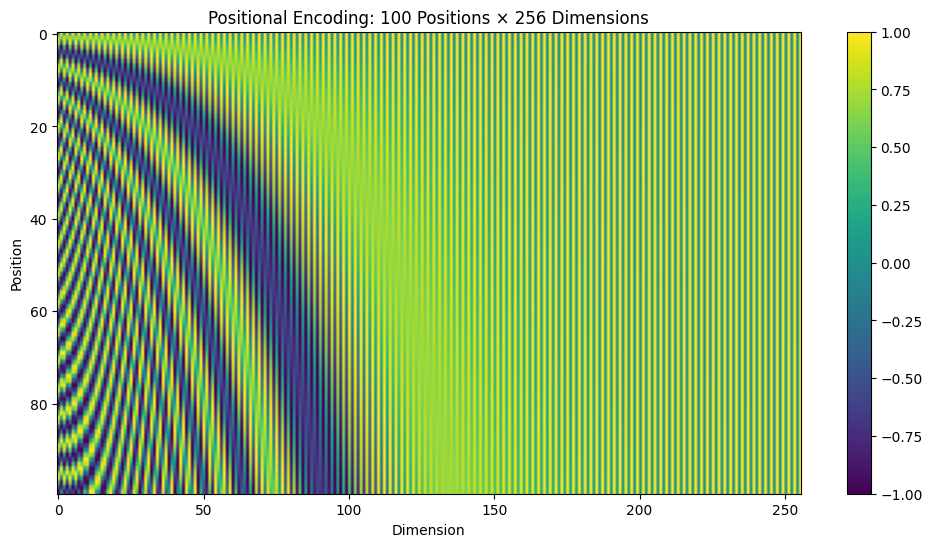

In [18]:
pe_chunk=pe.pe[:,:100,:].numpy().squeeze(0)
pe_chunk.shape

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.imshow(
    pe_chunk,
    aspect="auto"
)

plt.xlabel("Dimension")
plt.ylabel("Position")
plt.title("Positional Encoding: 100 Positions × 256 Dimensions")
plt.colorbar()

plt.show()

**The heatmap shows the sinusoidal positional encoding values for the first 100 positions across 256 dimensions. Different dimensions oscillate at different frequencies, allowing the Transformer to represent the position of each token and distinguish between different positions in a sequence.**

In [22]:
import sys
sys.path.insert( 0,  "/content/drive/MyDrive/Text-to-SQL-Generator-from-Transformers/starter")

**Transformer Encoder Implementation**

# **Task 2 – Implement the Transformer**

In [35]:
import torch.nn as nn
import torch
import numpy as np
from starter.embeddings import InputLayer,TokenEmbedding

In [25]:
from starter.dataset import make_loader

train_loader=make_loader("train_pairs.jsonl",sp,True)
dev_loader=make_loader("dev_pairs.jsonl",sp,False)
test_loader=make_loader("test_pairs.jsonl",sp,False)

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
test_pairs.jsonl: kept 15878, skipped 0


**Point Wise Feed Forward Implementation**

In [26]:
class Point_wise_feed_forward(nn.Module):
  def __init__(self,dmodel,dff):
    super().__init__()

    self.dmodel=dmodel
    self.dff=dff

    self.linear1=nn.Linear(self.dmodel,self.dff)
    self.linear2=nn.Linear(self.dff,self.dmodel)

  def forward(self,input):
    feed1=torch.relu(self.linear1(input))
    feed2=self.linear2(feed1)

    return feed2

**Scaled Dot Product Attention Implementation**

In [27]:
class Scaled_dot_product_Attention(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self,input,wq,wk,wv,dk,input_kv,masking,padding_mask):

    q=wq(input)

    if input_kv is not None:
      input=input_kv

    k=wk(input)
    v=wv(input)

    qk_t=torch.matmul(q,k.transpose(-2,-1))
    qk_t=qk_t/torch.sqrt(torch.tensor(dk,dtype=torch.float32,device=q.device))

    if padding_mask is not None:
      qk_t=qk_t.masked_fill(padding_mask,float('-inf'))

    if masking==True:
      masked=torch.triu(torch.ones(qk_t.shape[-2:],device=input.device),diagonal=1)
      masked=masked.masked_fill(masked==1,float('-inf'))
      qk_t=qk_t+masked

    attention_score=torch.softmax(qk_t,dim=-1)

    attention_output=torch.matmul(attention_score,v)

    return attention_output,attention_score

**Multihead Attention (CROSS Attention, Masked (Both pad and casual)**

In [28]:
class Multi_Head_Attention(nn.Module):
  def __init__(self,heads,dmodel):
    super().__init__()

    self.dmodel=dmodel
    self.heads=heads

    self.dh=self.dmodel//self.heads
    self.dk=self.dh
    self.dv=self.dh

    self.WQ=nn.ModuleList()
    self.WK=nn.ModuleList()
    self.WV=nn.ModuleList()

    self.WO=nn.Linear(self.dmodel,self.dmodel)

    for i in range(heads):
      self.WQ.append(nn.Linear(self.dmodel,self.dk))
      self.WK.append(nn.Linear(self.dmodel,self.dk))
      self.WV.append(nn.Linear(self.dmodel,self.dv))

    self.Scaled_dot_product_Attention=Scaled_dot_product_Attention()

  def forward(self,input,input_kv=None,masking=False,padding_mask=None):

    self.attention_output=[]
    self.attention_weights=[]

    for i in range(len(self.WQ)):
      attention_output,attention_weights=self.Scaled_dot_product_Attention(input,self.WQ[i],self.WK[i],self.WV[i],self.dk,input_kv,masking,padding_mask)

      self.attention_output.append(attention_output)
      self.attention_weights.append(attention_weights)

    attention_output=torch.cat(self.attention_output,dim=2)

    output=self.WO(attention_output)

    return output,self.attention_weights

**Decoder Layer Implementation**

In [29]:
class Decoder_layer(nn.Module):
    def __init__(self,dmodel,heads,dff,dropout):
        super().__init__()

        self.dmodel=dmodel
        self.heads=heads
        self.dff=dff
        self.dropout=nn.Dropout(dropout)

        self.Multi_Head_Attention_1=Multi_Head_Attention(self.heads,self.dmodel)
        self.Multi_Head_Attention_2=Multi_Head_Attention(self.heads,self.dmodel)

        self.Point_wise_feed_forward=Point_wise_feed_forward(self.dmodel,self.dff)

        self.layer_norm_1=nn.LayerNorm(self.dmodel)
        self.layer_norm_2=nn.LayerNorm(self.dmodel)
        self.layer_norm_3=nn.LayerNorm(self.dmodel)

    def forward(self,input,encoder_output,tgt_padding_mask,src_padding_mask):

        masked_attention_output,masked_attention_weights=self.Multi_Head_Attention_1(input,masking=True,padding_mask=tgt_padding_mask)

        masked_attention_output=self.dropout(masked_attention_output)

        layer_norm_1=self.layer_norm_1(input+masked_attention_output)

        cross_attention_output,cross_attention_weights=self.Multi_Head_Attention_2(layer_norm_1,encoder_output,padding_mask=src_padding_mask)

        cross_attention_output=self.dropout(cross_attention_output)

        layer_norm_2=self.layer_norm_2(layer_norm_1+cross_attention_output)

        pwff_ouptut=self.Point_wise_feed_forward(layer_norm_2)

        pwff_ouptut=self.dropout(pwff_ouptut)

        layer_norm_3=self.layer_norm_3(layer_norm_2+pwff_ouptut)

        return layer_norm_3

**Decoder Implementation**

In [38]:
class Decoder(nn.Module):
    """This is main transformer decoder class"""

    def __init__(self,n_layers,dmodel,heads,dff,dropout):
        super().__init__()

        self.n_layers=n_layers
        self.dmodel=dmodel
        self.heads=heads
        self.dff=dff
        self.dropout=dropout

        self.layers=nn.ModuleList()

        for i in range(n_layers):
            self.layers.append(Decoder_layer(self.dmodel,self.heads,self.dff,self.dropout))

    def forward(self,input,encoder_output,tgt_padding_mask,src_padding_mask):
      x=input

      for layer in self.layers:
          x=layer(x,encoder_output,tgt_padding_mask,src_padding_mask)
      return x

**Encpder Layer Implementation**

In [31]:
class Encoder_layer(nn.Module):
    def __init__(self,dmodel,heads,dff,dropout):
        super().__init__()

        self.dmodel=dmodel
        self.heads=heads
        self.dff=dff
        self.dropout=nn.Dropout(dropout)

        self.Multi_Head_Attention=Multi_Head_Attention(self.heads,self.dmodel)

        self.Point_wise_feed_forward=Point_wise_feed_forward(self.dmodel,self.dff)

        self.layer_norm_1=nn.LayerNorm(self.dmodel)
        self.layer_norm_2=nn.LayerNorm(self.dmodel)

    def forward(self,input,padding_mask):

        multi_head_attention_output,attention_weights=self.Multi_Head_Attention(input,padding_mask=padding_mask)

        multi_head_attention_output=self.dropout(multi_head_attention_output)

        layer_norm_1=self.layer_norm_1(input+multi_head_attention_output)

        pwff_ouptut=self.Point_wise_feed_forward(layer_norm_1)

        pwff_ouptut=self.dropout(pwff_ouptut)

        layer_norm_2=self.layer_norm_2(layer_norm_1+pwff_ouptut)

        return layer_norm_2

**Encoder Implementation**

In [32]:
class Encoder(nn.Module):
  """This is main transformer encoder class"""
  def __init__(self,n_layers,dmodel,heads,dff,masking,dropout):
    super().__init__()

    self.n_layers=n_layers
    self.dmodel=dmodel
    self.heads=heads
    self.dff=dff
    self.masking=masking
    self.dropout=dropout

    self.layers=nn.ModuleList()

    for i in range(n_layers):
      self.layers.append(Encoder_layer(self.dmodel,self.heads,self.dff,self.dropout))

  def forward(self,batch,padding_mask):
    for layer in self.layers:
      batch=layer(batch,padding_mask)

    return batch

**Tramsfomer Class Implementation : Main class covering whole pipeline**

In [36]:
class Transformers(nn.Module):
  def __init__(self,enc_layers,dec_layers,dmodel,heads,dff,dropout=0.1):
    super().__init__()

    self.enc_layers=enc_layers
    self.dec_layers=dec_layers
    self.dmodel=dmodel
    self.heads=heads
    self.dff=dff
    self.dropout=dropout

    self.shared=TokenEmbedding(sp.get_piece_size(),self.dmodel)
    self.input_layer=InputLayer(self.shared,self.dmodel)

    self.encoder=Encoder(self.enc_layers,self.dmodel,self.heads,self.dff,False,self.dropout)
    self.decoder=Decoder(self.dec_layers,self.dmodel,self.heads,self.dff,self.dropout)

    self.output_projection=nn.Linear(self.dmodel,sp.get_piece_size(),bias=False)

    self.output_projection.weight=self.shared.emb.weight

  def forward(self,src,tgt):

    src_padding_mask=(src==0).unsqueeze(1)
    tgt_padding_mask=(tgt==0).unsqueeze(1)

    batch_src=self.input_layer(src)
    batch_tgt=self.input_layer(tgt)

    encoder_output=self.encoder(batch_src,src_padding_mask)

    decoder_output=self.decoder(batch_tgt,encoder_output,tgt_padding_mask,src_padding_mask)

    logits=self.output_projection(decoder_output)

    return logits

In [41]:
model=Transformers(
    enc_layers=3,
    dec_layers=3,
    dmodel=256,
    heads=4,
    dff=1024,
    dropout=0.1
)

optimizer=torch.optim.Adam(
    model.parameters(),
    betas=(0.9,0.98),
    eps=1e-9
)

loss_function=nn.CrossEntropyLoss(
    ignore_index=0,
    label_smoothing=0.1
)

model.train()

for epoch in range(5):

    total_loss=0

    for batch_idx,(src,tgt) in enumerate(train_loader):

        if batch_idx==20:
            break

        optimizer.zero_grad()

        decoder_input=tgt[:,:-1]
        target=tgt[:,1:]

        logits=model(src,decoder_input)

        loss=loss_function(
            logits.reshape(-1,logits.size(-1)),
            target.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        print(f"Epoch {epoch+1}/10 | Batch {batch_idx+1}/80 | Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1}/10 | Average Loss: {total_loss/80:.4f}")

Epoch 1/10 | Batch 1/80 | Loss: 198.3261
Epoch 1/10 | Batch 2/80 | Loss: 46.8576
Epoch 1/10 | Batch 3/80 | Loss: 38.5355
Epoch 1/10 | Batch 4/80 | Loss: 36.3180
Epoch 1/10 | Batch 5/80 | Loss: 32.8117
Epoch 1/10 | Batch 6/80 | Loss: 30.0334
Epoch 1/10 | Batch 7/80 | Loss: 36.4775
Epoch 1/10 | Batch 8/80 | Loss: 31.0193
Epoch 1/10 | Batch 9/80 | Loss: 31.9300
Epoch 1/10 | Batch 10/80 | Loss: 31.4265
Epoch 1/10 | Batch 11/80 | Loss: 29.8275
Epoch 1/10 | Batch 12/80 | Loss: 27.9641
Epoch 1/10 | Batch 13/80 | Loss: 26.3954
Epoch 1/10 | Batch 14/80 | Loss: 24.8464
Epoch 1/10 | Batch 15/80 | Loss: 25.5682
Epoch 1/10 | Batch 16/80 | Loss: 24.8067
Epoch 1/10 | Batch 17/80 | Loss: 24.6517
Epoch 1/10 | Batch 18/80 | Loss: 24.0929
Epoch 1/10 | Batch 19/80 | Loss: 22.5348
Epoch 1/10 | Batch 20/80 | Loss: 21.5354
Epoch 1/10 | Average Loss: 9.5745
Epoch 2/10 | Batch 1/80 | Loss: 22.0147
Epoch 2/10 | Batch 2/80 | Loss: 22.5342
Epoch 2/10 | Batch 3/80 | Loss: 23.4726
Epoch 2/10 | Batch 4/80 | Loss: 20

# **Training the model**

In [42]:
import os
import csv

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer=Transformers(
    enc_layers=3,
    dec_layers=3,
    dmodel=256,
    heads=4,
    dff=1024,
    dropout=0.1
).to(device)

optimizer=torch.optim.Adam(
    transformer.parameters(),
    betas=(0.9,0.98),
    eps=1e-9
)

loss_function=nn.CrossEntropyLoss(
    ignore_index=0,
    label_smoothing=0.1
)


def get_lr(step,dmodel=256,warmup_steps=4000):
    return dmodel**(-0.5)*min(
        step**(-0.5),
        step*warmup_steps**(-1.5)
    )


previous_validation_loss=torch.inf

training_logs=[]

os.makedirs("checkpoints",exist_ok=True)


global_step=0

for epoch in range(20):

    losses=[]

    transformer.train()

    print("Epoch:",epoch+1,"/",20)

    for batch,(src,tgt) in enumerate(train_loader):

        src=src.to(device)
        tgt=tgt.to(device)

        global_step+=1

        lr=get_lr(global_step)

        for param_group in optimizer.param_groups:
            param_group["lr"]=lr

        optimizer.zero_grad()

        decoder_input=tgt[:,:-1]
        target=tgt[:,1:]

        logits=transformer(src,decoder_input)

        loss=loss_function(
            logits.reshape(-1,logits.size(-1)),
            target.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        losses.append(loss.item())


    average_training_loss=sum(losses)/len(losses)

    print("Average Training Loss:",average_training_loss)


    transformer.eval()

    validation_loss=[]

    with torch.no_grad():

        for batch,(src,tgt) in enumerate(dev_loader):

            src=src.to(device)
            tgt=tgt.to(device)

            decoder_input=tgt[:,:-1]
            target=tgt[:,1:]

            logits=transformer(src,decoder_input)

            loss=loss_function(
                logits.reshape(-1,logits.size(-1)),
                target.reshape(-1)
            )

            validation_loss.append(loss.item())


    average_validation_loss=sum(validation_loss)/len(validation_loss)

    print("Average Validation Loss:",average_validation_loss)
    print("Learning Rate:",lr)


    if previous_validation_loss>average_validation_loss:

        previous_validation_loss=average_validation_loss

        print("checkpoint saved!")

        training_logs.append(
            [epoch+1,average_training_loss,average_validation_loss,lr,"Yes"]
        )

        torch.save({
            "epoch":epoch+1,
            "model_state_dict":transformer.state_dict(),
            "optimizer_state_dict":optimizer.state_dict(),
            "validation_loss":average_validation_loss,
            "learning_rate":lr,
            "global_step":global_step
        },"checkpoints/best_transformer.pt")

    else:

        training_logs.append(
            [epoch+1,average_training_loss,average_validation_loss,lr,"No"]
        )


with open("checkpoints/training_logs.csv","w",newline="") as file:

    writer=csv.writer(file)

    writer.writerow([
        "Epoch",
        "Training Loss",
        "Validation Loss",
        "Learning Rate",
        "Checkpoint Saved"
    ])

    writer.writerows(training_logs)

Epoch: 1 / 20
Average Training Loss: 24.843390585480428
Average Validation Loss: 6.688608451323076
Learning Rate: 0.00021765364207877676
checkpoint saved!
Epoch: 2 / 20
Average Training Loss: 4.905740410732221
Average Validation Loss: 3.5545421874884404
Learning Rate: 0.0004353072841575535
checkpoint saved!
Epoch: 3 / 20
Average Training Loss: 3.293093693242847
Average Validation Loss: 2.9596472310297415
Learning Rate: 0.0006529609262363302
checkpoint saved!
Epoch: 4 / 20
Average Training Loss: 2.9389639620613157
Average Validation Loss: 2.808073659737905
Learning Rate: 0.000870614568315107
checkpoint saved!
Epoch: 5 / 20
Average Training Loss: 2.714812288760598
Average Validation Loss: 2.613302888292255
Learning Rate: 0.0009416880536915503
checkpoint saved!
Epoch: 6 / 20
Average Training Loss: 2.5122705550523947
Average Validation Loss: 2.4813221620790884
Learning Rate: 0.0008596396485666636
checkpoint saved!
Epoch: 7 / 20
Average Training Loss: 2.3770991475844627
Average Validation L

In [69]:
!git config --global user.name "M-Abdullah-Ali-2468"
!git config --global user.email "mabdullahali8642@gmail.com"

In [45]:
!git remote -v

origin	https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers.git (fetch)
origin	https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers.git (push)


In [46]:
!git add .
!git commit -m "Complete Transformer training"
!git push origin main

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> WikiSQL
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached WikiSQL
hint: 
hint: See "git help submodule" for more information.
[main a5fb34e] Complete Transformer training
 19 files changed, 201700 insertions(+)
 create mode 160000 WikiSQL
 create mode 100644 checkpoints/best_transformer.pt
 create mode 100644 checkpoints/training_logs.csv
 create mode 100644 dev_pairs.jsonl
 create mode 100644 requirements.txt
 create mode 100644 spm_corpus.txt
 create mode 100644 sql_sp.model
 create mode 100644 sql_sp.vocab
 create mode 100644 starter/__pycache__/data_prep.cpython-313.pyc
 create mode 100644 starter/__pycache__/dataset.cpytho

In [47]:
!git rm --cached -r WikiSQL

rm 'WikiSQL'


In [48]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    WikiSQL

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	WikiSQL/



In [59]:
!rm -rf WikiSQL

In [57]:
!git pull origin main --no-rebase

From https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers
 * branch            main       -> FETCH_HEAD
error: Your local changes to the following files would be overwritten by merge:
  WikiSQL
Merge with strategy ort failed.


In [61]:
%%writefile .gitignore
WikiSQL/
__pycache__/
*.pyc
checkpoints/

Overwriting .gitignore


In [62]:
!git pull origin main --no-rebase

From https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers
 * branch            main       -> FETCH_HEAD
error: Your local changes to the following files would be overwritten by merge:
  WikiSQL
Merge with strategy ort failed.


In [64]:
!git add .gitignore
!git commit -m "Add gitignore"

[main 86f88dc] Add gitignore
 1 file changed, 4 insertions(+)
 create mode 100644 .gitignore


In [65]:
!git pull origin main --no-rebase

From https://github.com/M-Abdullah-Ali-2468/Text-to-SQL-Generator-from-Transformers
 * branch            main       -> FETCH_HEAD
Auto-merging .gitignore
CONFLICT (add/add): Merge conflict in .gitignore
Automatic merge failed; fix conflicts and then commit the result.


In [66]:
!git checkout --ours .gitignore
!git add .gitignore
!git commit -m "Merge remote main"

Updated 1 path from the index
[main 0165901] Merge remote main


In [70]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
